In [16]:
#  In the following code we will import all necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
import somoclu

from numpy.ma.core import ceil
from scipy.spatial import distance #distance calculation
from sklearn.preprocessing import MinMaxScaler #normalisation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score #scoring
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib import animation, colors
import pandas as pd

import ipywidgets as widgets
from ipywidgets import interact, interactive, Layout
import glob

In [4]:
# We will now load the input data


df = pd.read_excel('FRANCE_DATASET.xlsx')
df


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
0,France,Raismes,59,Moderate,1,Good,30,Good,4,Good,59,Moderate,50.3892,3.4858
1,France,Pontarlier,56,Moderate,1,Good,35,Good,0,Good,56,Moderate,46.9061,6.3547
2,France,Haubourdin,48,Good,1,Good,28,Good,4,Good,48,Good,50.6092,2.9869
3,France,Beaune,39,Good,1,Good,26,Good,1,Good,39,Good,47.0250,4.8397
4,France,Paita,27,Good,0,Good,27,Good,0,Good,10,Good,-5.0911,-81.1064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,France,Maubeuge,39,Good,1,Good,22,Good,4,Good,39,Good,50.2775,3.9734
450,France,Creil,50,Good,1,Good,21,Good,5,Good,50,Good,49.2583,2.4833
451,France,Villeurbanne,70,Moderate,1,Good,54,Moderate,0,Good,70,Moderate,45.7667,4.8803
452,France,Soyaux,38,Good,1,Good,38,Good,1,Good,26,Good,45.6403,0.1978


In [5]:
df.info() # to see the datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             454 non-null    object 
 1   City                454 non-null    object 
 2   AQI Value           454 non-null    int64  
 3   AQI Category        454 non-null    object 
 4   CO AQI Value        454 non-null    int64  
 5   CO AQI Category     454 non-null    object 
 6   Ozone AQI Value     454 non-null    int64  
 7   Ozone AQI Category  454 non-null    object 
 8   NO2 AQI Value       454 non-null    int64  
 9   NO2 AQI Category    454 non-null    object 
 10  PM2.5 AQI Value     454 non-null    int64  
 11  PM2.5 AQI Category  454 non-null    object 
 12  lat                 454 non-null    float64
 13  lng                 454 non-null    float64
dtypes: float64(2), int64(5), object(7)
memory usage: 49.8+ KB


In [6]:
features = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]
#keep only the interested features for clustering and named the x to save time and space on coding

X = df[features]
X

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
0,59,1,30,4,59
1,56,1,35,0,56
2,48,1,28,4,48
3,39,1,26,1,39
4,27,0,27,0,10
...,...,...,...,...,...
449,39,1,22,4,39
450,50,1,21,5,50
451,70,1,54,0,70
452,38,1,38,1,26


In [7]:
#data normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_scaled

array([[0.27559055, 0.33333333, 0.31506849, 0.22222222, 0.34751773],
       [0.2519685 , 0.33333333, 0.38356164, 0.        , 0.32624113],
       [0.18897638, 0.33333333, 0.28767123, 0.22222222, 0.26950355],
       ...,
       [0.36220472, 0.33333333, 0.64383562, 0.        , 0.42553191],
       [0.11023622, 0.33333333, 0.42465753, 0.05555556, 0.11347518],
       [0.20472441, 0.33333333, 0.17808219, 0.27777778, 0.28368794]])

In [18]:
# The first is to set the number of rows of my SOM and  the second is to set the number of Columns

rowsnum = widgets.IntSlider()
columnum = widgets.IntSlider()

display (rowsnum)
display (columnum)


IntSlider(value=0)

IntSlider(value=0)

In [26]:
#I use the dimensions I entered in the slider to train the SOM
data = np.float32(X_scaled)
som = somoclu.Somoclu(n_columns = columnum.value, n_rows = rowsnum.value, data=data, compactsupport=False)
%time som.train()

CPU times: user 150 ms, sys: 35.4 ms, total: 186 ms
Wall time: 42.4 ms


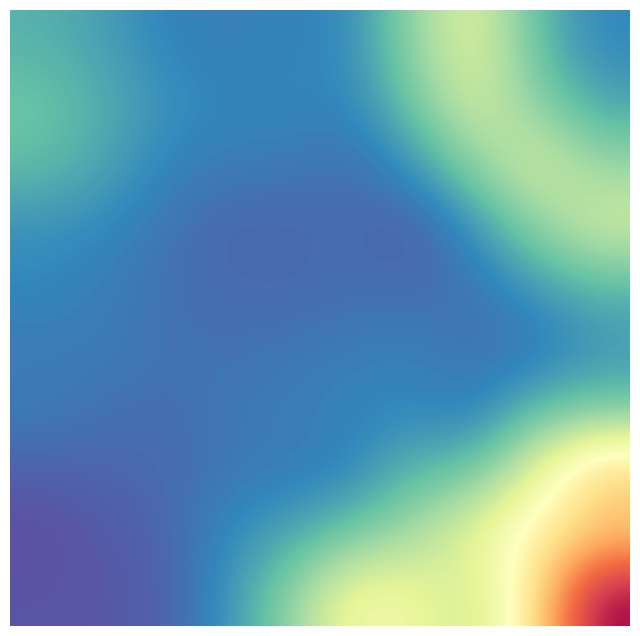

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.8/dist-packages/matplotlib/pyplot.py'>

In [27]:
#som.view_umatrix()
som.view_umatrix()

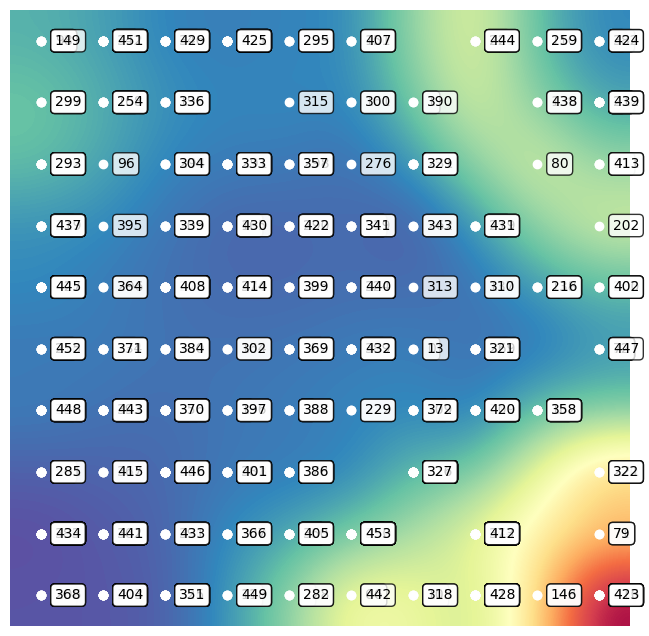

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.8/dist-packages/matplotlib/pyplot.py'>

In [28]:
# We can also show the U-Matrix with the labels (numbers) of the rows of our input data mapped on top
# depending  on the size of your lattice, it may take some seconds for this figure to display.
labels = range(454) #454 is the total records of my dataset
som.view_umatrix(bestmatches=True, labels=labels)

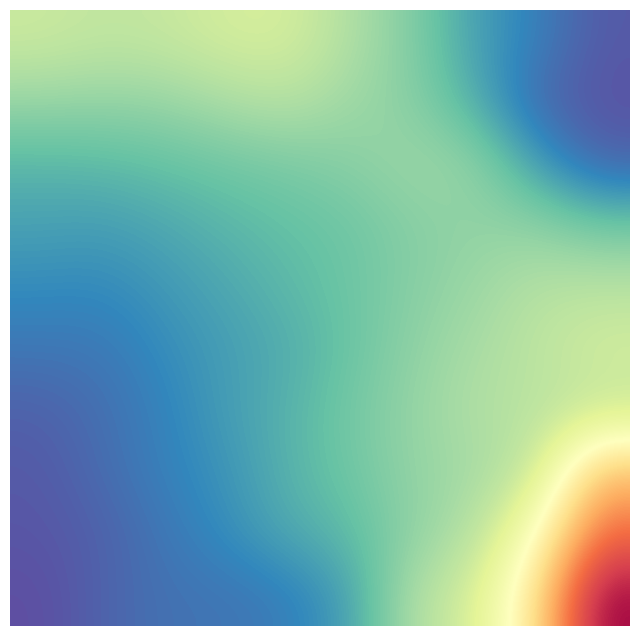

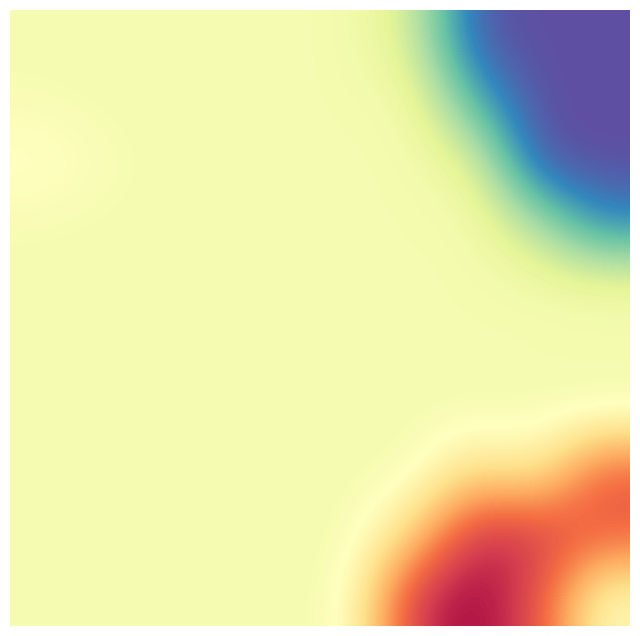

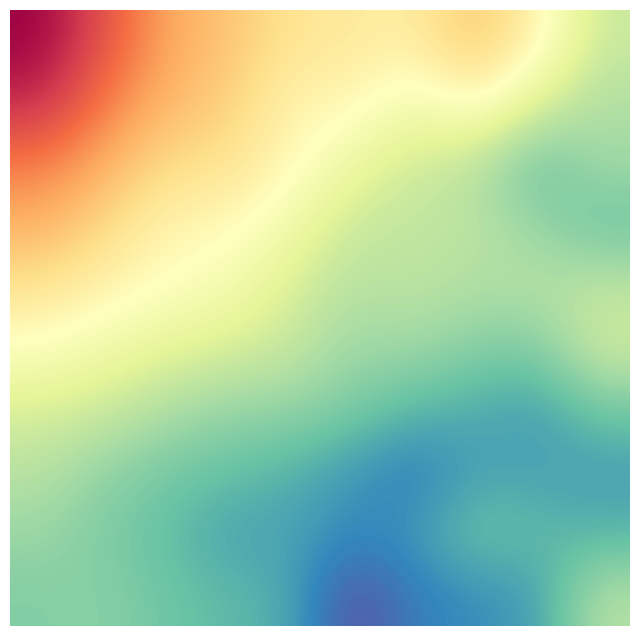

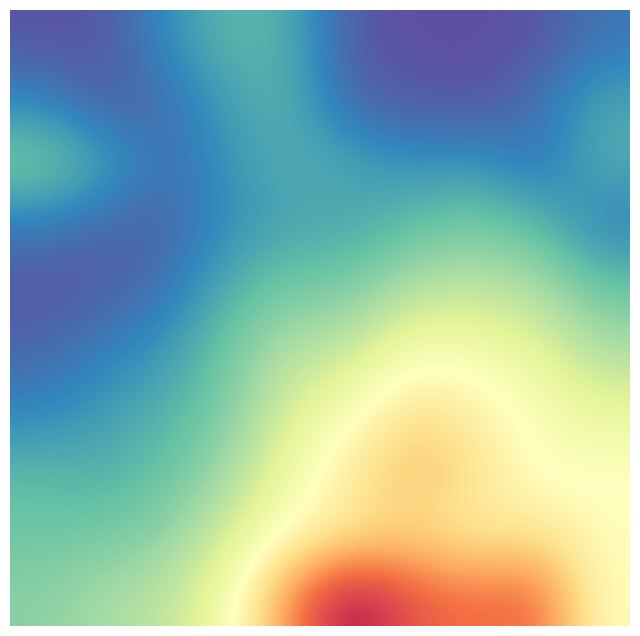

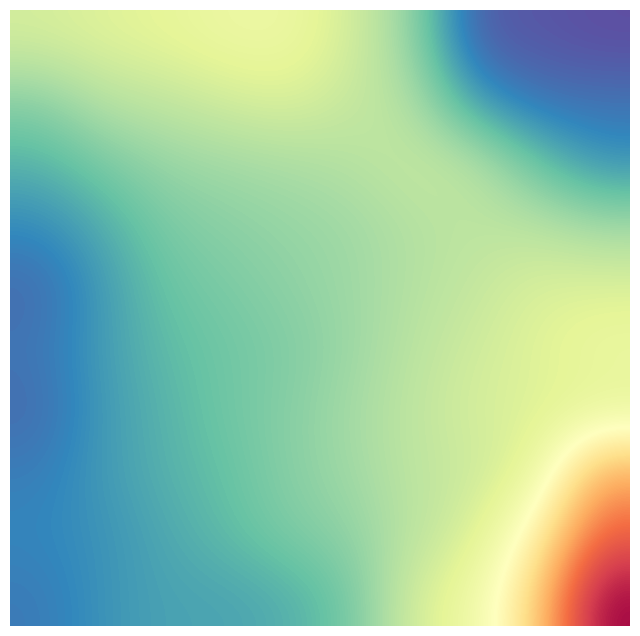

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.8/dist-packages/matplotlib/pyplot.py'>

In [29]:
som.view_component_planes() #all the u-matrix for every variable will be included in clustering 

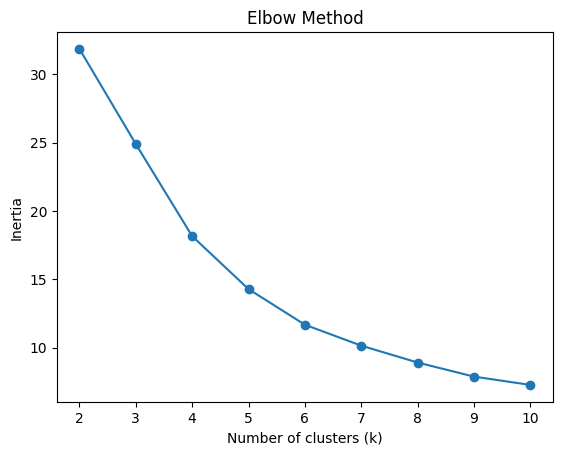

In [33]:
#elbow method to reveal the best k-value
from sklearn.cluster import KMeans

inertias = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [34]:
# clustering the nodes and plot the nodes of the SOM
km = KMeans(n_clusters=6)
som.cluster(km)
node_cl= som.clusters
print(node_cl)

[[5 5 5 5 5 5 5 3 3 3]
 [5 5 5 5 5 5 5 3 3 3]
 [5 5 5 5 5 5 5 0 3 3]
 [1 1 5 5 5 1 0 0 0 3]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 0 0 0 0 0 2]
 [1 1 1 1 0 0 0 4 4 2]
 [1 1 1 1 0 0 4 4 4 2]]


In [35]:
# Get the best matching unit (bm) from the SOM
bm = som.bmus

# assign the clusters to each row in your input data
cluster_ids = []
for i in range(len(bm)):
  cluster_ids.append(som.clusters[som.bmus[i, 1], som.bmus[i, 0]])
#print a list with clusters_ids
print (cluster_ids)

#Save the clusters in a dataframe, join it with the original data and save it in a excel file.
df_new = pd.DataFrame(cluster_ids)
df_new
df = df.join(df_new)
df.to_excel("france3.xlsx")


[0, 5, 0, 1, 3, 1, 1, 0, 3, 1, 1, 3, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 3, 2, 1, 5, 1, 0, 0, 5, 0, 0, 1, 3, 1, 1, 5, 1, 5, 1, 1, 1, 1, 1, 0, 5, 5, 1, 1, 0, 0, 0, 5, 1, 0, 0, 0, 4, 1, 3, 3, 1, 0, 1, 1, 0, 1, 1, 1, 1, 2, 0, 0, 3, 5, 4, 0, 1, 2, 3, 1, 5, 0, 5, 1, 5, 5, 5, 5, 5, 5, 1, 4, 1, 4, 5, 4, 5, 5, 5, 0, 0, 5, 1, 4, 1, 3, 1, 1, 3, 0, 5, 5, 5, 5, 1, 0, 1, 0, 0, 0, 4, 1, 0, 0, 4, 5, 5, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 3, 1, 1, 1, 4, 0, 0, 4, 4, 2, 5, 1, 5, 0, 0, 1, 1, 1, 1, 3, 5, 1, 5, 0, 2, 1, 5, 5, 5, 5, 5, 2, 0, 1, 1, 0, 0, 1, 5, 5, 1, 1, 1, 0, 0, 5, 0, 1, 1, 1, 1, 5, 5, 0, 0, 1, 5, 5, 1, 1, 5, 0, 1, 3, 3, 2, 0, 1, 0, 0, 1, 1, 1, 3, 1, 1, 4, 0, 4, 0, 0, 1, 2, 0, 4, 3, 2, 2, 4, 0, 0, 1, 5, 1, 1, 5, 5, 5, 1, 1, 5, 5, 1, 5, 1, 5, 1, 0, 0, 4, 0, 5, 5, 5, 5, 5, 1, 1, 0, 1, 3, 0, 1, 0, 4, 4, 0, 5, 1, 0, 0, 5, 5, 5, 1, 1, 0, 5, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 5, 1, 1, 4, 5, 5, 1, 1, 1, 0, 0, 0, 4, 0, 0, 5, 1, 1, 4, 1, 1, 0, 2, 0, 0, 1, 0, 0, 1, 5, 1, 1, 1, 

In [7]:
# read file
df = pd.read_excel("france3.xlsx")

# I rename the column 0 to cluster 
df = df.rename(columns={0: "cluster"})

# numeric variables that we want to keep
features = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

# to see the stats per cluster
cluster_stats = df.groupby("cluster")[features].agg(["min", "max", "mean", "median"])

print(cluster_stats)

        AQI Value                         CO AQI Value                       \
              min  max        mean median          min max      mean median   
cluster                                                                       
0              30   69   55.268041   55.0            1   1  1.000000    1.0   
1              43   80   59.843478   59.0            1   2  1.008696    1.0   
2             100  151  131.250000  143.0            1   2  1.437500    1.0   
3              28   84   68.586207   71.0            2   3  2.103448    2.0   
4              24   54   37.970930   38.0            1   1  1.000000    1.0   
5              27   57   35.600000   32.0            0   0  0.000000    0.0   

        Ozone AQI Value                       NO2 AQI Value                \
                    min max       mean median           min max      mean   
cluster                                                                     
0                     8  37  23.154639   23.0            

In [9]:
import pandas as pd
import folium

#rad excel file 
df = pd.read_excel("france3.xlsx")

# rename cluster column 
df = df.rename(columns={0: "cluster"})

# only points in France 
df_fr = df[
    (df["lat"] >= 41.0) & (df["lat"] <= 51.5) &
    (df["lng"] >= -5.5) & (df["lng"] <= 9.8)
].copy()

# for the cetner of the map
center_lat = df_fr["lat"].mean()
center_lng = df_fr["lng"].mean()

# I create the map
m = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=6,
    tiles="CartoDB positron",
    control_scale=True
)

# colouring the clusters 
colors = {
    5: "lime",        # very good air quality
    4: "seagreen",    # good air quality
    0: "yellow",      # satisfactory air quality
    3: "darkorange",  # moderately polluted air quality
    1: "red",         # poor air quality
    2: "maroon"       # very poor air quality
}

# adding markers
for _, row in df_fr.iterrows():
    
    cluster = row["cluster"]
    
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=6,
        color="black",
        weight=1,
        fill=True,
        fill_color=colors.get(cluster, "gray"),
        fill_opacity=0.9,
        popup=f"""
        City: {row['City']}<br>
        Cluster: {cluster}<br>
        AQI: {row['AQI Value']}
        """
    ).add_to(m)

# map title 
title_html = '''
<h3 align="center" style="font-size:20px"><b>Air Quality Clusters in France</b></h3>
'''

m.get_root().html.add_child(folium.Element(title_html))

# legend
legend_html = '''
<div style="
position: fixed; 
bottom: 50px; left: 50px; width: 200px; height: 210px; 
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding:10px;
">

<b>Air Quality Classes</b><br>

<i style="background:lime;width:12px;height:12px;float:left;margin-right:8px"></i>
Very Good<br>

<i style="background:seagreen;width:12px;height:12px;float:left;margin-right:8px"></i>
Good<br>

<i style="background:yellow;width:12px;height:12px;float:left;margin-right:8px"></i>
Satisfactory<br>

<i style="background:darkorange;width:12px;height:12px;float:left;margin-right:8px"></i>
Moderatelly polluted<br>

<i style="background:red;width:12px;height:12px;float:left;margin-right:8px"></i>
Poor<br>

<i style="background:maroon;width:12px;height:12px;float:left;margin-right:8px"></i>
Very poor

</div>
'''
# add the legend as a custom hit on the map 
m.get_root().html.add_child(folium.Element(legend_html))

# SAVE MAP AS HTML 
m.save("france_air_quality_clusters_map.html")

# show on notebook
m

In [23]:
df = pd.read_excel("france3.xlsx")

# rename for ArcGIS
df = df.rename(columns={
    "lng": "X",
    "lat": "Y"
})

# save an excel file 
df.to_excel("france_arcgis3.xlsx", index=False)

In [1]:
cluster_labels = {
    5: "Very good",
    4: "Good",
    0: "Satisfactory",
    3: "Moderately polluted",
    1: "Poor",
    2: "Very poor"
}

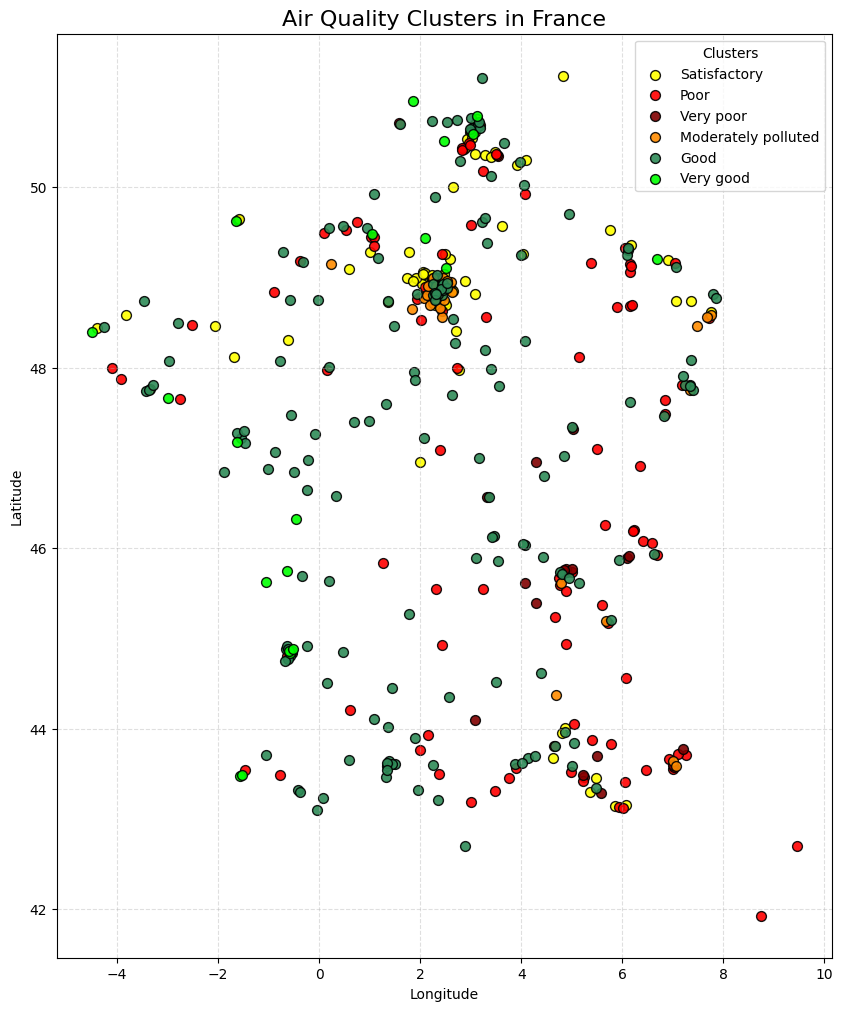

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# read excel
df = pd.read_excel("france3.xlsx")
df = df.rename(columns={0: "cluster"})

# keep only points in France ( by lat and lon)
df_fr = df[
    (df["lat"] >= 41.0) & (df["lat"] <= 51.5) &
    (df["lng"] >= -5.5) & (df["lng"] <= 9.8)
].copy()

# colour clusters
colors = {
    5: "lime",
    4: "seagreen",
    0: "yellow",
    3: "darkorange",
    1: "red",
    2: "maroon"
}

# create plot
plt.figure(figsize=(10, 12))
#attributes for the plot
for cluster_id, group in df_fr.groupby("cluster"):
    plt.scatter(
        group["lng"],
        group["lat"],
        s=50,
        c=colors[cluster_id],
        edgecolors="black",
        label=cluster_labels[cluster_id],
        alpha=0.9
    )

plt.title("Air Quality Clusters in France", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Clusters")
plt.grid(True, linestyle="--", alpha=0.4)

# save
plt.savefig("france_air_quality_clusters2.pdf", bbox_inches="tight")
plt.savefig("france_air_quality_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

0     97
1    115
2     16
3     29
4    172
5     25
Name: cluster, dtype: int64


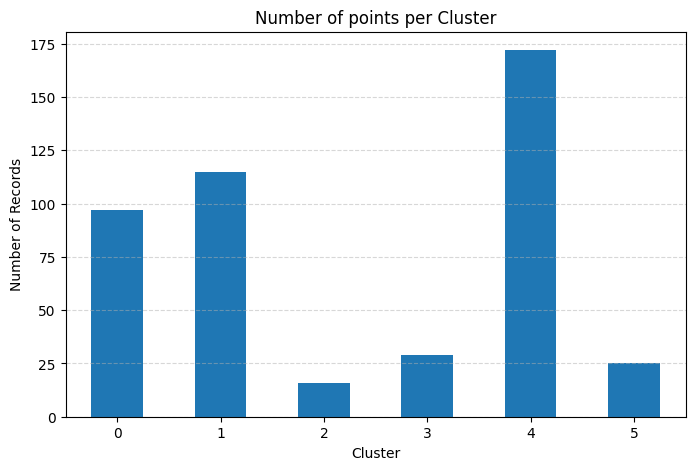

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_excel("france3.xlsx")
df = df.rename(columns={0: "cluster"})

# count record per cluster
cluster_counts = df["cluster"].value_counts().sort_index()

print(cluster_counts)

# graph
plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar")

plt.title("Number of points per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

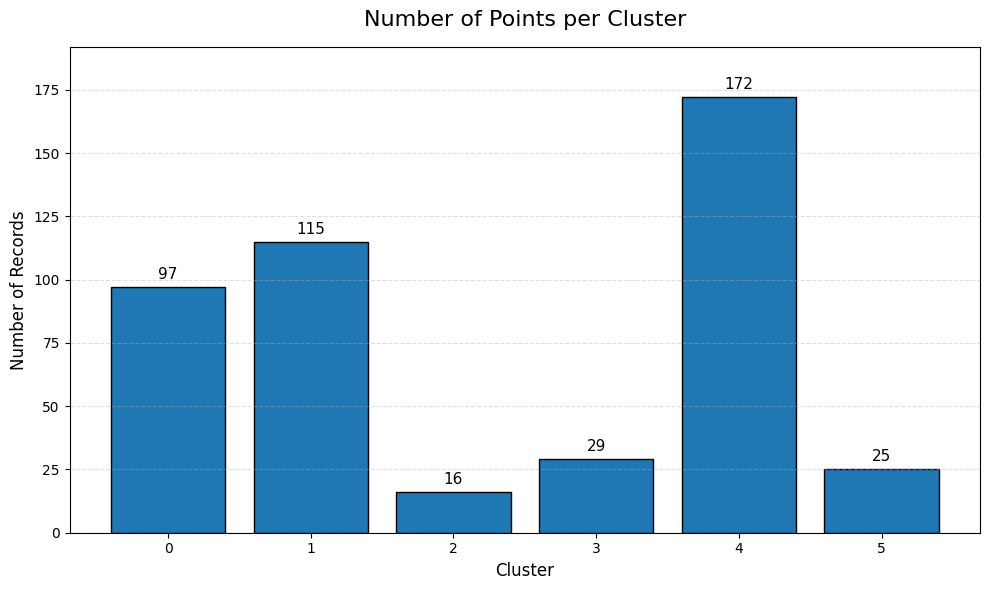

In [3]:
#it counts the record for every cluster
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(cluster_counts.index.astype(str), cluster_counts.values,
               edgecolor="black", linewidth=1)

plt.title("Number of Points per Cluster", fontsize=16, pad=15)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.ylim(0, cluster_counts.max() + 20)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 2, f"{int(h)}",
             ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

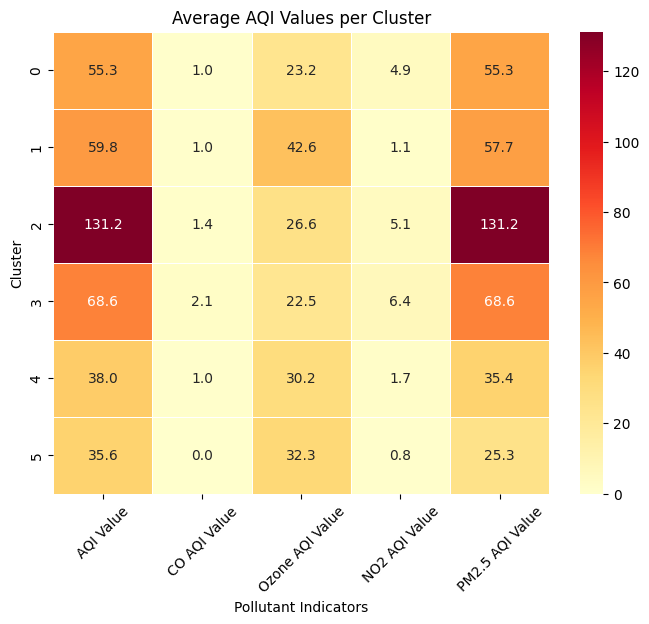

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# calculate mean values per cluster
cluster_means = df.groupby("cluster")[[
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]].mean()

plt.figure(figsize=(8,6))
# characteristics of heatmap
sns.heatmap(
    cluster_means,
    annot=True,
    cmap="YlOrRd",
    fmt=".1f",
    linewidths=0.5
)
plt.xticks(rotation=45)
plt.title("Average AQI Values per Cluster")
plt.xlabel("Pollutant Indicators")
plt.ylabel("Cluster")

plt.show()

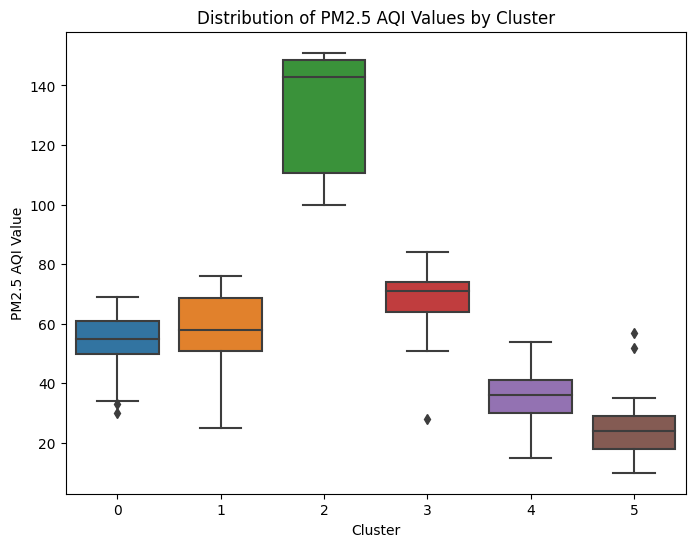

In [21]:
plt.figure(figsize=(8,6)) #size of figure
#characteristics of boxplot
sns.boxplot(
    x="cluster",
    y="PM2.5 AQI Value",
    data=df
)

plt.title("Distribution of PM2.5 AQI Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("PM2.5 AQI Value")

plt.show()